# Analiza akordov in harmonskih progresij v priljubljenih pesmih

Namen projektne naloge je združiti znanje programiranja in glasbene teorije ter ob analizi priljubljenih pesmi odgovoriti na zanimiva vprašanja, kot so:
- Ali veliko pesmi uporablja iste glasbene vzorce?
- Se pri posameznih žanrih ponavlja isti vzorec?
- Kateri avtorji v svojih pesmih najbolj ponavljajo vzorce?
- Katere akorde se mi najbolj splača naučiti, da lahko zaigram čim več pesmi?
- Kako se med žanri razlikuje tempo pesmi?


V projektni nalogi analiziram **17.106 pesmi**, ki sem jih zajela s spletne strani [Guitar Tuna](https://guitartuna.com/collections/top-chords). Tam so pesmi objavljene z akordi in ključem, v katerem so napisane, tako da sem z nekaj znanja glasbene teorije lahko analizirala njihove harmonske značilnosti ter jih primerjala med seboj.

## Kazalo

1. [Uvoz in pregled podatkov](#1-uvoz-in-pregled-podatkov)
2. [Najpogostejši akordi](#2-najpogostejši-akordi)
3. [Priprava tonalitet in podatkov za harmonsko analizo](#3-priprava-tonalitet-in-podatkov-za-harmonsko-analizo)
    1. [Izbira analitičnega ključa](#31-izbira-analitičnega-ključa)
    2. [Ocena ujemanja ključa z akordi](#32-ocena-ujemanja-ključa-z-akordi)
    3. [Izbor pesmi za analizo harmonskih vzorcev](#33-izbor-pesmi-za-analizo-harmonskih-vzorcev)
4. [Pretvorba akorda v stopnjo](#4-pretvorba-akorda-v-stopnjo)
5. [Izluščenje harmonskih progresij](#5-izluščenje-harmonskih-progresij)
6. [Najpogostejše progresije](#6-najpogostejše-progresije)
    1. [Najpogostejše 3-akordne progresije po pesmih](#61-najpogostejše-3-akordne-progresije-po-pesmih)
    2. [Najpogostejše 4-akordne progresije po pesmih](#62-najpogostejše-4-akordne-progresije-po-pesmih)
    3. [Skupno število pojavitev](#63-skupno-število-pojavitev)
7. [Harmonska raznolikost posameznih pesmi](#7-harmonska-raznolikost-posameznih-pesmi)
8. [Harmonska osredotočenost najpogostejših izvajalcev](#8-harmonska-osredotočenost-najpogostejših-izvajalcev)
9. [Harmonska osredotočenost žanrov](#9-harmonska-osredotočenost-žanrov)
    1. [Tipične 4-akordne progresije po žanrih](#91-tipične-4-akordne-progresije-po-žanrih)
10. [Tempo pesmi po žanrih](#10-tempo-pesmi-po-žanrih)
11. [Zaključek](#11-zaključek)


## 1. Uvoz in pregled podatkov

Najprej uvozimo podatke iz `pesmi_ociscene.csv`.

**OPOMBA:** Stolpca z akordi sta v datoteki shranjena kot niza, zato ju pretvorimo nazaj v Pythonov seznam.

In [1]:
import ast
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

pesmi = pd.read_csv("pesmi_ociscene.csv")

# literal_eval pretvori niz v seznam
pesmi["uporabljeni_akordi"] = pesmi["uporabljeni_akordi"].apply(ast.literal_eval)
pesmi["zaporedje_akordov"] = pesmi["zaporedje_akordov"].apply(ast.literal_eval)

Poglejmo si osnovne informacije o zbranih podatkih.

Za vsako pesem imamo naslednje podatke: naslov, izvajalec, ključ (tonaliteta), bpm (*beats per minute*, tempo), capo (položaj kapodastra), leto, žanr, vsi uporabljeni akordi, celotno zaporedje akordov skozi pesem (da lahko analiziramo *progresije*), število različnih akordov in dolžino zaporedja akordov.

In [2]:
print(f"Število pesmi: {len(pesmi)}")
print(f"Število stolpcev: {len(pesmi.columns)}")

stolpci_za_prikaz = [stolpec for stolpec in pesmi.columns if stolpec != "url"]
pesmi[stolpci_za_prikaz].head()

Število pesmi: 17106
Število stolpcev: 12


,naslov,izvajalec,kljuc,bpm,capo,leto,zanr,uporabljeni_akordi,zaporedje_akordov,stevilo_razlicnih_akordov,dolzina_zaporedja
0,Perfect,Ed Sheeran,Ab major,95,1,2017,Pop,"[G, Em, C, D]","[G, G, Em, C, D, G, Em, C, D, G, Em, C, G, D, ...",4,102
1,Yellow,Coldplay,B major,87,4,2000,Rock,"[B, F#, E, G#m, F#m]","[B, B, B, B, B, B, F#, F#, E, E, B, B, B, F#, ...",5,74
2,Wonderwall,Oasis,F# minor,87,2,1995,Rock,"[Em, G, D, A, C]","[Em, G, D, A, Em, G, D, A, Em, G, D, A, Em, G,...",5,170
3,Knockin' On Heaven's Door,Bob Dylan,G major,70,0,1973,Folk,"[G, D, Am, C]","[G, D, Am, G, D, C, G, D, Am, G, D, C, G, D, A...",4,63
4,Let It Be,The Beatles,C major,72,0,1970,Rock,"[C, G, Am, F]","[C, G, Am, F, C, G, F, C, C, G, Am, F, C, G, F...",4,138


## 2. Najpogostejši akordi

**OPOMBA: Poenostavljeni akordi** <br>
Pred analizo sem podatke akordov očistila in uvedla nekaj poenostavitev:
- odstranila sem dodatke akordov (maj7, sus4, add9, ...),
- ohranila sem razliko med dur in mol akordi,
- odstranila sem basovske tone pri obratih (npr. C/E → C),
- poenotila sem enharmonične zapise (npr. Bb = A#).

**OPOMBA: Enharmonični toni**
Če si predstavljamo klavirsko tipkovnico, črno tipko lahko zapišemo na dva načina: znižamo belo tipko nad njo (*b*) ali zvišamo belo tipko pod njo (*#*). Vse zapise z *b* sem pretvorila v ustrezne zapise z *#*.

**OPOMBA: Kapodaster** <br>
Kapodaster (*capo*) je pripomoček, ki se namesti na vrat brenkala, da pretisne strune in tako skrajša njihovo igralno višino ter s tem zviša njihovo višino. Pri kitari kapodaster na `n`-tem polju zviša akord za `n` poltonov. Npr. če je *capo = 4*, se vsi akordi zvišajo za 4 poltone, torej 2 tona.

Akordi na spletni strani so namenjeni kitaristu in niso nujno ustrezni originalni melodiji skladbe. Če se pri pesmi uporablja kapodaster, so dejanski akordi višji, zato je bilo pomembno zajeti podatek `capo`.

Dejansko zveneči akordi se torej lahko razlikujejo od igranih akordov, če jih kapodaster transponira. V analizi bomo zato ločili
 
- **igrane akorde**: tisti, ki so originalno zapisani v vzorcu in jih kitarist *prime*,
- **zveneče akorde**: tisti, ki jih dejansko slišimo - zanje upoštevamo kapodaster in pridejo v poštev pri harmonski analizi.

### 2.1 Igrani akordi
Najprej preverimo, kateri akordi se najpogosteje pojavljajo v zapisih za igranje, da bo vsak kitarist vedel, katere se mu najbolj splača naučiti.
Ker uporabljamo stolpec `uporabljeni_akordi`, se vsak akord v posamezni pesmi šteje največ enkrat.

In [3]:
pogostost_igrani = pesmi["uporabljeni_akordi"].explode().value_counts()
pogostost_igrani.head(10)

G     8906
C     8084
D     7962
A     6799
F     6407
E     5693
Am    5441
Em    5140
B     4415
A#    4366
Name: uporabljeni_akordi, dtype: int64

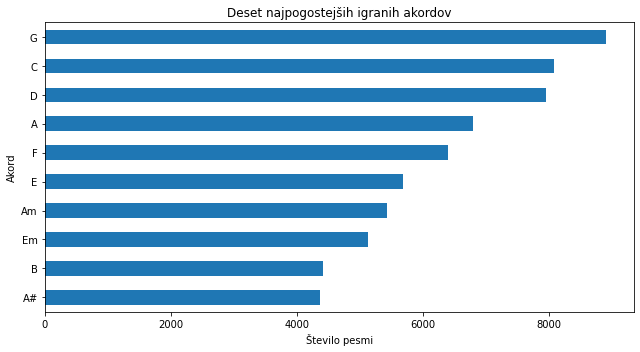

In [4]:
plt.figure(figsize=(9, 5))

pogostost_igrani.head(10).sort_values().plot(kind="barh")

plt.xlabel("Število pesmi")
plt.ylabel("Akord")
plt.title("Deset najpogostejših igranih akordov")
plt.tight_layout()
plt.show()

### 2.2 Zveneči akordi
Za izračun zvenečih akordov vsak akord transponiramo navzgor za toliko poltonov, kot znaša položaj kapodastra.

In [5]:
toni = [
    "C", "C#", "D", "D#", "E", "F",
    "F#", "G", "G#", "A", "A#", "B"
]


def transponiraj_akord(akord, capo):
    """Akord transponira navzgor za podano število poltonov."""

    if capo == 0:
        return akord

    # Preverimo, ali je akord molski.
    molski = akord.endswith("m")

    if molski:
        osnovni_ton = akord[:-1]
    else:
        osnovni_ton = akord

    indeks = toni.index(osnovni_ton)
    novi_indeks = (indeks + capo) % 12
    novi_akord = toni[novi_indeks]

    if molski:
        novi_akord += "m"

    return novi_akord

def transponiraj_seznam(akordi, capo):
    return [transponiraj_akord(akord, capo) for akord in akordi]

pesmi["zveneci_akordi"] = pesmi.apply(
    lambda vrstica: transponiraj_seznam(
        vrstica["uporabljeni_akordi"],
        vrstica["capo"]
    ),
    axis=1
)

pesmi["zvenece_zaporedje_akordov"] = pesmi.apply(
    lambda vrstica: transponiraj_seznam(
        vrstica["zaporedje_akordov"],
        vrstica["capo"]
    ),
    axis=1
)

In [6]:
# Preverimo pravilnost funkcije za transponiranje:
assert transponiraj_akord("G", 2) == "A"
assert transponiraj_akord("Em", 1) == "Fm"

In [7]:
pogostost_zveneci = pesmi["zveneci_akordi"].explode().value_counts()
pogostost_zveneci.head(10)

G     7113
C     6205
D     6123
E     6087
F     5842
A     5811
B     5508
F#    5078
D#    4709
C#    4689
Name: zveneci_akordi, dtype: int64

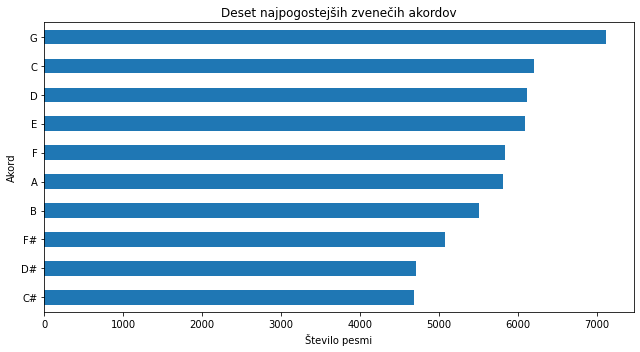

In [8]:
plt.figure(figsize=(9, 5))

pogostost_zveneci.head(10).sort_values().plot(kind="barh")

plt.xlabel("Število pesmi")
plt.ylabel("Akord")
plt.title("Deset najpogostejših zvenečih akordov")
plt.tight_layout()
plt.show()

### 2.3 Primerjava pogostosti *igranih* in *zvenečih* akordov

*Igrani* akordi so akordi, ki jih kitarist prime glede na zapis, *zveneči* akordi pa upoštevajo tudi položaj kapodastra. Pri obeh analizah vsak akord v posamezni pesmi štejemo največ enkrat, torej gledamo, v koliko pesmih se pojavlja.

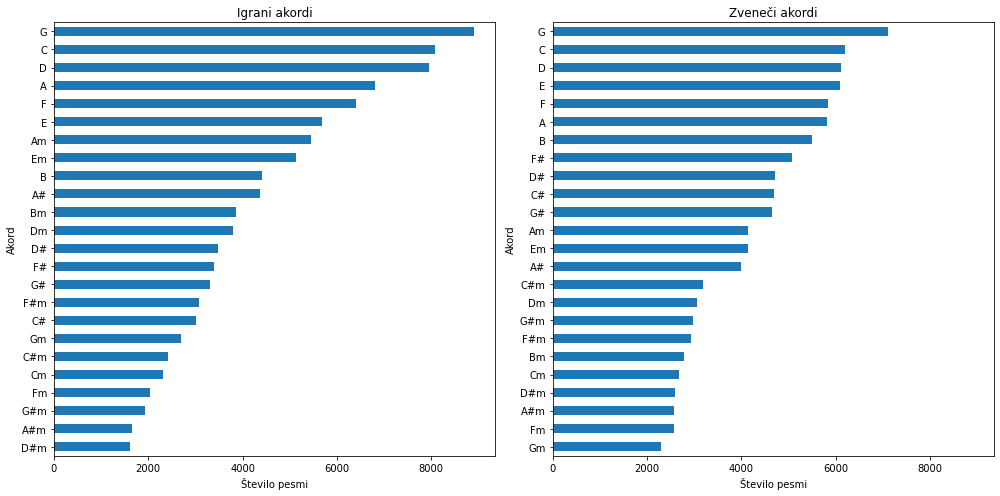

In [9]:
fig, osi = plt.subplots(1, 2, figsize=(14, 7))

pogostost_igrani.sort_values().plot(kind="barh", ax=osi[0])
osi[0].set_title("Igrani akordi")
osi[0].set_xlabel("Število pesmi")
osi[0].set_ylabel("Akord")

pogostost_zveneci.sort_values().plot(kind="barh", ax=osi[1])
osi[1].set_title("Zveneči akordi")
osi[1].set_xlabel("Število pesmi")
osi[1].set_ylabel("Akord")

# Naslednje vrstice dodamo, da dobimo enake lestvice na vodoravni osi.
najvec = max(pogostost_igrani.max(), pogostost_zveneci.max())
osi[0].set_xlim(0, najvec * 1.05)
osi[1].set_xlim(0, najvec * 1.05)

plt.tight_layout()
plt.show()

## 3. Priprava tonalitet in podatkov za harmonsko analizo

Da lahko primerjamo vzorce v različnih tonalitetah, akorde pretvorimo v stopnje lestvice - vsak akord pretvorimo v njegovo *razdaljo* od osnovnega tona oz. ključa. Tako na primer zaporedji

- `G - D - Em - C` (ključ G)
- `A - E - F#m - D` (ključ A)

postaneta isti vzorec `I - V - vi - IV`.

Najprej si poglejmo vse možne glasbene lestvice: dur in mol lestvico za vsak ton (tonov je 12). Vsaka lestvica vsebuje 7 tonov, ki jih bomo pretvorili v stopnje `I-VII` oziroma `i-vii` (velika tiskana rimska številka predstavlja dur, mala pa mol).

In [10]:
# Vseh 12 tonov kromatične lestvice.
# Uporabljamo enake oznake kot pri akordih (C#, D#, ...).
toni = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# Intervali durove lestvice (v poltonih).
# C dur: C D E F G A B
intervali_dur = [0, 2, 4, 5, 7, 9, 11]

# Intervali molove lestvice.
# A mol: A B C D E F G
intervali_mol = [0, 2, 3, 5, 7, 8, 10]

# Slovarja, kamor bomo shranili vse lestvice.
durove_lestvice = {}
molove_lestvice = {}

# Za vsak možen ton sestavimo durovo in molovo lestvico.
for ton in toni:
    indeks = toni.index(ton)
    
    durove_lestvice[ton] = [
        toni[(indeks + interval) % 12]
        for interval in intervali_dur
    ]
    
    molove_lestvice[ton] = [
        toni[(indeks + interval) % 12]
        for interval in intervali_mol
    ]
    
# Npr. C-dur kličemo z durove_lestvice["C"], A-mol kličemo z molove_lestvice["A"]
print("C-dur:", durove_lestvice["C"])
print("A-mol:", molove_lestvice["A"])


C-dur: ['C', 'D', 'E', 'F', 'G', 'A', 'B']
A-mol: ['A', 'B', 'C', 'D', 'E', 'F', 'G']


Lestvice smo sestavili predvsem za ponazprotev glasbenega ozadja analize, da vidimo, kateri toni pripadajo posameznim durovim oz. molovim lestvicam. V nadaljevanju pa bomo za programsko določanje pripadnosti akordov tonalitetam in določanje stopenj uporabili slovarje intervalov, saj je tak zapis za računanje bolj priročen.

Podatki o ključu so napisani kot *major* (dur) in *minor* (mol). Poleg tega se pojavljajo različni ekvivalentni zapisi enharmoničnih tonov. Te olepšave smo pri akordih naredili še pred uvažanjem podatkov, za ključe pa to naredimo zdaj.

In [11]:
# Slovar za poenotenje enharmoničnih tonov. 
# Vse tone z nižajem (*b*) pretvorimo v ekvivalentni ton z višajem (*#*).
# Tako bodo oznake ključev enake oznakam akordov.
enharmonicni = {
    "Bb": "A#",
    "Db": "C#",
    "Eb": "D#",
    "Gb": "F#",
    "Ab": "G#"
}

def razberi_kljuc(kljuc):
    """Iz zapisa ključa (npr. 'Bb major' ali 'F# minor') vrne ('A#', 'major'), ('F#', 'minor')"""
    ton, nacin = kljuc.split()
    
    # Če je ton zapisan z nižajem, ga pretvorimo v ekvivalentnega.
    ton = enharmonicni.get(ton, ton)
    
    return ton, nacin

### 3.1 Izbira analitičnega ključa

Pri pregledovanju podatkov sem naletela na težavo, ki nam bo analizo podatkov precej otežila. Na spletni strani ključi pri pesmih namreč niso napisani dosledno; pri nekaterih pesmih je ključ napisan glede na *igrane* akorde, pri drugih glede na *zveneče* akorde. Da bomo akorde lahko ključu ustrezno pretvarjali v stopnje, moramo preveriti, ali se ključ pri posamezni pesmi bolje ujema z *igranimi* akordi ali z *zvenečimi* z upoštevanjem kapodastra.

**PRIMER**:

**Perfect**

| Podani ključ | Transponirani ključ | Zveneči akordi     |
|--------------|---------------------|--------------------|
| Ab major     | A major             | G#, Fm, C#, D# ... |

Akordi se bolje ujemajo z Ab major, torej je podani ključ pravi in ga ni treba transponirati.

**Yellow**
| Podani ključ | Transponirani ključ | Zveneči akordi     |
|--------------|---------------------|--------------------|
| B major     | D# major             | D#, A#, G# ... |     

Akordi se bolje ujemajo z D# major, zato uporabimo transponirani ključ (kapodaster uporabimo tudi na ključu).

In [12]:
def transponiraj_kljuc(kljuc, capo):
    """Ključ transponira navzgor za toliko poltonov, kot določa kapodaster.
    Funkcija uporablja funkcijo razberi_kljuc(), zato hkrati poenoti enharmonične tone."""
    
    if pd.isna(kljuc):
        return None
    
    ton, nacin = razberi_kljuc(kljuc)
    
    indeks_tona = toni.index(ton)
    novi_indeks = (indeks_tona + int(capo)) % 12
    
    novi_ton = toni[novi_indeks]
    
    return f"{novi_ton} {nacin}"

In [13]:
# Preverimo pravilnost funkcije za transponiranje ključa:
assert transponiraj_kljuc("Bb major", 1) == "B major"

In [14]:
def akord_se_ujema_s_kljucem(akord, kljuc):
    """Preveri, ali je dani akord diatoničen v podanem ključu.
    Vrne: 
        True - akord se ujema s ključem, 
        False - akord se ne ujema s ključem.
        
    Pri molih dovolimo tako molovo kot durovo dominanto. Npr. v a-molu sta zato dovoljena Em in E,
    saj se v praksi pogosto uporablja harmonski mol."""
    
    if pd.isna(akord) or pd.isna(kljuc):
        return False
    
    tonika, nacin = razberi_kljuc(kljuc)
    
    je_molov = akord.endswith("m")
    
    if je_molov:
        osnovni_ton = akord[:-1]
        kakovost = "minor"
    else:
        osnovni_ton = akord
        kakovost = "major"
        
    if osnovni_ton not in toni:
        return False
    
    interval = (toni.index(osnovni_ton) - toni.index(tonika)) % 12
    
    if nacin == "major":
        # Diatonični trozvoki v duru:
        #
        # I   = dur
        # ii  = mol
        # iii = mol
        # IV  = dur
        # V   = dur
        # vi  = mol
        #
        # Sedma stopnja je zmanjšana, vendar smo zmanjšane
        # akorde pri čiščenju poenostavili, zato je tukaj ne vključimo.
        dovoljeni_akordi = {
            0: {"major"},
            2: {"minor"},
            4: {"minor"},
            5: {"major"},
            7: {"major"},
            9: {"minor"}
        }
    
    elif nacin == "minor":
        # Diatonični trozvoki v naravnem molu:
        #
        # i   = mol
        # III = dur
        # iv  = mol
        # v   = mol
        # VI  = dur
        # VII = dur
        #
        # Na peti stopnji dovolimo tudi durov akord,
        # saj je durova dominanta zelo pogosta v harmonskem molu.
        dovoljeni_akordi = {
            0: {"minor"},
            3: {"major"},
            5: {"minor"},
            7: {"minor", "major"},
            8: {"major"},
            10: {"major"}
        }
        
    else:
        return False
    
    if interval not in dovoljeni_akordi:
        return False
    return kakovost in dovoljeni_akordi[interval]

In [15]:
def oceni_ujemanje_kljuca(akordi, kljuc):
    """Izračuna delež akordov, ki se diatonično ujemajo s podanim ključem.
    Rezultat je število med 0 in 1.

    Primer:
        1.0 pomeni, da se ujemajo vsi akordi;
        0.75 pomeni, da se ujemajo trije od štirih akordov;
        0.0 pomeni, da se ne ujema noben akord.
    """

    if not isinstance(akordi, list) or len(akordi) == 0:
        return 0

    if pd.isna(kljuc):
        return 0

    # Za vsak akord preverimo, ali se ujema s ključem.
    ujemanja = [
        akord_se_ujema_s_kljucem(akord, kljuc)
        for akord in akordi
    ]

    # True se pri računanju obravnava kot 1,
    # False pa kot 0.
    #
    # Povprečje zato predstavlja delež ujemajočih se akordov.
    return sum(ujemanja) / len(ujemanja)

Za lažje razumevanje procesa poglejmo primer:

In [16]:
perfect = pesmi.loc[pesmi["naslov"] == "Perfect"].iloc[0]
yellow = pesmi.loc[pesmi["naslov"] == "Yellow"].iloc[0]

print("Perfect:")
print(
    "Podani ključ:",
    perfect["kljuc"],
    oceni_ujemanje_kljuca(
        perfect["zveneci_akordi"],
        perfect["kljuc"]
    )
)

print(
    "Transponirani ključ:",
    transponiraj_kljuc(perfect["kljuc"], perfect["capo"]),
    oceni_ujemanje_kljuca(
        perfect["zveneci_akordi"],
        transponiraj_kljuc(perfect["kljuc"], perfect["capo"])
    )
)

print("\nYellow:")
print(
    "Podani ključ:",
    yellow["kljuc"],
    oceni_ujemanje_kljuca(
        yellow["zveneci_akordi"],
        yellow["kljuc"]
    )
)

print(
    "Transponirani ključ:",
    transponiraj_kljuc(yellow["kljuc"], yellow["capo"]),
    oceni_ujemanje_kljuca(
        yellow["zveneci_akordi"],
        transponiraj_kljuc(yellow["kljuc"], yellow["capo"])
    )
)

Perfect:
Podani ključ: Ab major 1.0
Transponirani ključ: A major 0.0

Yellow:
Podani ključ: B major 0.0
Transponirani ključ: D# major 0.8


Za vsako pesem torej primerjamo podani ključ in ključ, ki ga dobimo s transponiranjem s kapodastrom.
Za analizo izberemo tistega, s katerim se ujema več zvenečih akordov; poimenujemo ga *analitični ključ*.

In [17]:
def izberi_analiticni_kljuc(vrstica):
    """Za pesem izbere ključ, ki se bolje ujema z njenimi zvenečimi akordi.

    Primerjamo:
        1. ključ, kot je zapisan v podatkih;
        2. isti ključ, transponiran za capo.

    Funkcija vrne tri podatke:
        - izbrani ključ,
        - oceno ujemanja,
        - izvor izbranega ključa.
    """

    # Preberemo podatke trenutne pesmi.
    podani_kljuc = vrstica["kljuc"]
    capo = vrstica["capo"]
    zveneci_akordi = vrstica["zveneci_akordi"]

    # Če ključ manjka, ga ne moremo določiti.
    if pd.isna(podani_kljuc):
        return pd.Series({
            "analiticni_kljuc": None,
            "ocena_kljuca": 0,
            "izvor_kljuca": "manjka"
        })

    # Prvi kandidat je ključ, kot je zapisan v podatkih.
    kandidat_1 = podani_kljuc

    # Drugi kandidat je ključ, transponiran za capo.
    kandidat_2 = transponiraj_kljuc(
        podani_kljuc,
        capo
    )

    # Izračunamo, kako dobro se vsak kandidat ujema
    # z različnimi zvenečimi akordi pesmi.
    ocena_1 = oceni_ujemanje_kljuca(
        zveneci_akordi,
        kandidat_1
    )

    ocena_2 = oceni_ujemanje_kljuca(
        zveneci_akordi,
        kandidat_2
    )

    # Če je transponirani ključ strogo boljši,
    # izberemo transponiranega.
    if ocena_2 > ocena_1:
        return pd.Series({
            "analiticni_kljuc": kandidat_2,
            "ocena_kljuca": ocena_2,
            "izvor_kljuca": "transponiran"
        })

    # Če sta oceni enaki, obdržimo podani ključ.
    #
    # To je smiselno predvsem pri capo = 0,
    # ko sta oba kandidata enaka, in pri neodločenih primerih,
    # kjer nimamo razloga za spreminjanje podatka.
    return pd.Series({
        "analiticni_kljuc": kandidat_1,
        "ocena_kljuca": ocena_1,
        "izvor_kljuca": "podan"
    })

Zdaj to funkcijo uporabimo za vse vrstice:

In [18]:
# Funkcija za vsako pesem vrne tri nove vrednosti.
rezultati_kljucev = pesmi.apply(
    izberi_analiticni_kljuc,
    axis=1
)

# Dobljene stolpce dodamo v glavno podatkovno tabelo.
pesmi[["analiticni_kljuc", "ocena_kljuca", "izvor_kljuca"]] = rezultati_kljucev

Preštejmo, pri koliko pesmih smo obdržali podani ključ in pri koliko smo izbrali transponirani ključ. Izračunamo še odstotke.

In [19]:
pregled_kljucev = (
    pesmi["izvor_kljuca"]
    .value_counts()
    .rename_axis("izvor_kljuca")
    .reset_index(name="stevilo_pesmi")
)

pregled_kljucev["delez_pesmi"] = (
    pregled_kljucev["stevilo_pesmi"] / len(pesmi) * 100
).round(2)

pregled_kljucev

,izvor_kljuca,stevilo_pesmi,delez_pesmi
0,transponiran,9847,57.56
1,podan,7259,42.44


Kot vidimo, je pri več kot pol pesmi ključ s spletne strani bilo treba transponirati. To kaže, da je bila korekcija ključa pred nadaljnjo harmonsko analizo pomemben korak.

### 3.2 Ocena ujemanja ključa z akordi

Ocena ključa predstavlja delež zvenečih akordov v pesmi, ki se ujemajo z izbrano tonaliteto. Vrednost 1 pomeni popolno ujemanje, vrednost 0 pa pomeni, da se z izbranim ključem ne ujema noben akord.

In [20]:
# Prikažemo osnovne statistike ocen:
# število vrednosti, povprečje, standardni odklon, najmanjšo vrednost, kvartile in največjo vrednost.

pesmi["ocena_kljuca"].describe()

count    17106.000000
mean         0.824275
std          0.206204
min          0.000000
25%          0.666667
50%          0.857143
75%          1.000000
max          1.000000
Name: ocena_kljuca, dtype: float64

Preštejmo pesmi, pri katerih se z izbranim ključem ujema manj kot polovica različnih zvenečih akordov. Izračunajmo še delež pesmi s slabo oceno ključa.

In [21]:
stevilo_nizkih_ocen = (pesmi["ocena_kljuca"] < 0.5).sum()
delez_nizkih_ocen = stevilo_nizkih_ocen / len(pesmi) * 100

print(f"Pesmi z oceno pod 0,5: {stevilo_nizkih_ocen}")
print(f"Delež pesmi z oceno pod 0,5: {delez_nizkih_ocen:.2f} %")

Pesmi z oceno pod 0,5: 1302
Delež pesmi z oceno pod 0,5: 7.61 %


### 3.3 Izbor pesmi za analizo harmonskih vzorcev

V nadaljnjo analizo vključimo samo pesmi, pri katerih se z izbranim ključem ujema vsaj polovica različnih zvenečih akordov (`ocena_kljuca >= 0.5`). Tako zmanjšamo vpliv napačno določenih ključev in izrazito nediatoničnih pesmi.

In [22]:
# Ustvarimo novo podatkovno tabelo samo z dovolj zanesljivimi pesmimi.

pesmi_zanesljive = pesmi[pesmi["ocena_kljuca"] >= 0.5].copy()

print(f"Vseh pesmi: {len(pesmi)}")
print(f"Pesmi za analizo vzorcev: {len(pesmi_zanesljive)}")

delez_ohranjenih = (len(pesmi_zanesljive) / len(pesmi) * 100)

print(f"Ohranjenih je {delez_ohranjenih:.2f} % pesmi.")

Vseh pesmi: 17106
Pesmi za analizo vzorcev: 15804
Ohranjenih je 92.39 % pesmi.


## 4. Pretvorba akorda v stopnjo

Za vsak akord določimo njegov interval od osnovnega tona tonalitete.
Rimska številka predstavlja stopnjo; velika tiskana pomeni durov akord, mala tiskana pa molov akord.

**OPOMBA**: Funkcija akordov, ki ne pripadajo neposredno osnovni durovi oziroma molovi lestvici (*nediatonični akordi*), ne upošteva. Z njimi bi dobili veliko različnih, redkih vzorcev, nas pa bolj zanimajo najpogostejši. Kromatične stopnje se še vedno pravilno izračunajo, npr. bVII ali #iv, vendar jih na koncu pretvorimo v *None*.

Zdaj vsak *zveneč* akord v pesmi pretvorimo v stopnjo glede na ključ pesmi.

In [23]:
# Oznake stopenj glede na oddaljenost od tonike (osnovnega tona) v poltonih:
#
# Za durovo tonaliteto:
# C -> I
# C# -> #I
# D -> II
# D# -> bIII
# ...
# Pri kromatičnih stopnjah bi lahko isto stopnjo včasih zapisali na več načinov, npr. #I ali bII.
# Tukaj izberemo enoten zapis, da bomo vzorce lahko primerjali.

stopnje_dur = {
    0: "I",
    1: "bII",
    2: "II",
    3: "bIII",
    4: "III",
    5: "IV",
    6: "#IV",
    7: "V",
    8: "bVI",
    9: "VI",
    10: "bVII",
    11: "VII"
}

# Pri molovi tonaliteti uporabljamo naravno molovo lestvico kot osnovo.
#
# Primer v a-molu:
# A  -> I
# B  -> II
# C  -> III
# D  -> IV
# E  -> V
# F  -> VI
# G  -> VII
#
# Ton G# bi bil na primer #VII.
stopnje_mol = {
    0: "I",
    1: "bII",
    2: "II",
    3: "III",
    4: "#III",
    5: "IV",
    6: "#IV",
    7: "V",
    8: "VI",
    9: "#VI",
    10: "VII",
    11: "#VII"
}


def mala_rimska_stopnja(stopnja):
    """Rimski del oznake stopnje spremeni v male črke, kadar je akord molov.
    Predznak b ali # ostane nespremenjen."""
    
    # Če ima stopnja na začetku predznak b ali #, ga ločimo od rimske številke.
    if stopnja.startswith(("b", "#")):
        return stopnja[0] + stopnja[1:].lower()
    
    # Če predznaka ni, v male črke spremeni celoten niz.
    return stopnja.lower()

In [24]:
def akord_v_stopnjo(akord, kljuc):
    """Zveneči akord pretvori v stopnjo glede na analitični ključ pesmi.
    Če akorda ali ključa ni mogoče obdelati, vrne None.
    
    Funkcija najprej izračuna interval med toniko in osnovnim tonom akorda. 
    Nato s slovarjem stopnje_dur oz. stopnje_mol določi rimsko stopnjo.
    Če akord ni diatoničen v podanem ključu, funkcija vrne None.
    
    Pri molih dovolimo na peti stopnji tako molovo kot durovo dominanto. 
    Npr. v a-molu je Em -> v, E -> V."""
    
    if pd.isna(akord) or pd.isna(kljuc):
        return None
    
    tonika, nacin = razberi_kljuc(kljuc)
    
    je_molov = akord.endswith("m")
    
    # Iz imena akorda odstranimo oznako m, da dobimo samo njegov osnovni ton.
    if je_molov:
        osnovni_ton_akorda = akord[:-1]
    else:
        osnovni_ton_akorda = akord
        
    # Varnostno preverimo, ali oba tona obstajata v naši kromatični lestvici.
    if tonika not in toni or osnovni_ton_akorda not in toni:
        return None
    
    # Poiščemo položaj tonike in osnovnega tona akorda v kromatični lestvici.
    indeks_tonike = toni.index(tonika)
    indeks_akorda = toni.index(osnovni_ton_akorda)
    
    interval = (indeks_akorda - indeks_tonike) % 12 # %12 uporabimo, ker se lestvica po 12 tonih ponovi.
    
    if nacin == "major":
        stopnja = stopnje_dur[interval]
    elif nacin == "minor":
        stopnja = stopnje_mol[interval]
    else:
        return None
    
    if je_molov:
        stopnja = mala_rimska_stopnja(stopnja)
        
    # Preverimo, ali je dobljena stopnja diatonična v ustrezni tonaliteti.
    if nacin == "major":
        # Diatonični akordi v duru.
        dovoljene_stopnje = {"I", "ii", "iii", "IV", "V", "vi"}
    else:
        # Diatonični akordi v molu. Dodamo tudi durovo dominanto V.
        dovoljene_stopnje = {"i", "III", "iv", "v", "V", "VI", "VII"}
        
    if stopnja not in dovoljene_stopnje:
        return None
        
    return stopnja

Za primerjavo harmonskih vzorcev med pesmimi pretvorimo zveneča zaporedja akordov v zaporedja stopenj glede na analitični ključ posamezne pesmi.

In [25]:
def zaporedje_v_stopnje(zaporedje_akordov, kljuc):
    """Pretvori celotno zaporedje akordov v zaporedje stopenj.
    Če posamezen akord ni diatoničen, funkcija na njegovo mesto doda None."""
    
    stopnje = []
    
    for akord in zaporedje_akordov:
        stopnja = akord_v_stopnjo(akord, kljuc)
        stopnje.append(stopnja)
        
    return stopnje

Ustvarimo nov stolpec in za vsako pesem pretvorimo celotno zveneče zaporedje v stopnje.

In [26]:
pesmi_zanesljive["zvenece_stopnje"] = pesmi_zanesljive.apply(
    lambda vrstica: zaporedje_v_stopnje(
        vrstica["zvenece_zaporedje_akordov"],
        vrstica["analiticni_kljuc"]
    ),
    axis=1
)

pesmi_zanesljive[
    ["naslov", "zvenece_zaporedje_akordov", "analiticni_kljuc", "zvenece_stopnje"]
].head()

,naslov,zvenece_zaporedje_akordov,analiticni_kljuc,zvenece_stopnje
0,Perfect,"[G#, G#, Fm, C#, D#, G#, Fm, C#, D#, G#, Fm, C...",Ab major,"[I, I, vi, IV, V, I, vi, IV, V, I, vi, IV, I, ..."
1,Yellow,"[D#, D#, D#, D#, D#, D#, A#, A#, G#, G#, D#, D...",D# major,"[I, I, I, I, I, I, V, V, IV, IV, I, I, I, V, I..."
2,Wonderwall,"[F#m, A, E, B, F#m, A, E, B, F#m, A, E, B, F#m...",F# minor,"[i, III, VII, None, i, III, VII, None, i, III,..."
3,Knockin' On Heaven's Door,"[G, D, Am, G, D, C, G, D, Am, G, D, C, G, D, A...",G major,"[I, V, ii, I, V, IV, I, V, ii, I, V, IV, I, V,..."
4,Let It Be,"[C, G, Am, F, C, G, F, C, C, G, Am, F, C, G, F...",C major,"[I, V, vi, IV, I, V, IV, I, I, V, vi, IV, I, V..."


## 5. Izluščenje harmonskih progresij

Iz zaporedja stopenj izluščimo vsa zaporedna 3- in 4-členska zaporedja. Uporabimo **drseče okno** dolžine 3 oziroma 4. Iz zaporedja `I - V - vi - IV - I` tako pri dolžini 4 dobimo zaporedji:

- `I - V - vi - IV`,
- `V - vi - IV - I`.

Če ima katera stopnja vrednost `None`, takega vzorca ne upoštevamo.

Ciklične zamike obravnavamo kot isto **progresijo**. Zaporedja `I - V - vi - IV`, `V - vi - IV - I` in drugi ciklični zamiki tako dobijo istega kanoničnega predstavnika.

Pred izluščenjem odstranimo tudi zaporedne ponovitve iste stopnje, saj večkrat zapored zapisani isti akord ne predstavlja harmonske spremembe.

**Opomba:** Za zapis vzorcev uporabljamo n-terice (`tuple`) in ne seznamov. N-terice so nespremenljive, zato jih lahko uporabljamo kot ključe v slovarjih in jih štejemo z metodo `value_counts()`.

In [27]:
def kanonicni_vzorec(vzorec):
    """Vse ciklične zamike istega vzorca predstavi
    z eno samo izbrano obliko.

    Primer:
    (I, V, vi, IV),
    (V, vi, IV, I),
    (vi, IV, I, V) in
    (IV, I, V, vi)

    bodo predstavljali isto progresijo."""

    # Sestavimo vse možne ciklične zamike vzorca.
    rotacije = []

    for i in range(len(vzorec)):
        rotacija = vzorec[i:] + vzorec[:i]
        rotacije.append(rotacija)

    # Kot skupnega predstavnika izberemo
    # najmanjšo rotacijo po Pythonovem urejanju.
    return min(rotacije)

In [28]:
# Preverimo, da ciklični zamiki predstavljajo isti vzorec:
assert kanonicni_vzorec(("I", "V", "vi", "IV")) == kanonicni_vzorec(("V", "vi", "IV", "I"))

# Preverimo, da različni progresiji ne postaneta enaki:
assert kanonicni_vzorec(("I", "V", "vi", "IV")) != kanonicni_vzorec(("I", "IV", "v", "I"))

In [29]:
def vzorci_dolzine(stopnje, dolzina):
    """Iz zaporedja stopenj izlušči vse zaporedne vzorce podane dolžine.
    Vzorce, ki vsebujejo None, preskoči.
    
    Vrne tuple."""
    
    vzorci = []
    
    for i in range(len(stopnje) - dolzina + 1):
        vzorec = stopnje[i:i + dolzina]
        if None in vzorec:
            continue
        vzorec = kanonicni_vzorec(tuple(vzorec))
        vzorci.append(tuple(vzorec))
        
    return vzorci

V zaporedjih se lahko isti akord pojavi večkrat zapored. Takšne ponovitve ne predstavljajo spremembe harmonije. Pred iskanjem progresij zato zaporedne ponovitve iste stopnje združimo v eno samo pojavitev. Vrednost `None`, ki označuje nediatonični akord, še vedno ohranimo kot prekinitev zaporedja.

In [30]:
def odstrani_zaporedne_ponovitve(stopnje):
    """Odstrani zaporedne ponovitve iste stopnje.
    Vrednost None ostane v zaporedju in še vedno
    predstavlja prekinitev med diatoničnimi odseki.
    """

    # Če je seznam prazen, vrnemo prazen seznam.
    if len(stopnje) == 0:
        return []

    rezultat = [stopnje[0]]

    # Vsako naslednjo stopnjo dodamo le,
    # če se razlikuje od prejšnje.
    for stopnja in stopnje[1:]:
        if stopnja != rezultat[-1]:
            rezultat.append(stopnja)

    return rezultat

### 3- in 4-akordni vzorci

Dodajmo nove stolpce. Za vsako pesem ustvarimo seznam vseh 3- in 4-akordnih vzorcev, ki se pojavijo v njenem zaporedju stopenj.

In [31]:
pesmi_zanesljive["zvenece_stopnje_brez_ponovitev"] = (
    pesmi_zanesljive["zvenece_stopnje"]
    .apply(odstrani_zaporedne_ponovitve)
)

pesmi_zanesljive["vzorci_3_brez_ponovitev"] = (
    pesmi_zanesljive["zvenece_stopnje_brez_ponovitev"]
    .apply(lambda stopnje: vzorci_dolzine(stopnje, 3))
)

pesmi_zanesljive["vzorci_4_brez_ponovitev"] = (
    pesmi_zanesljive["zvenece_stopnje_brez_ponovitev"]
    .apply(lambda stopnje: vzorci_dolzine(stopnje, 4))
)

## 6. Najpogostejše progresije

Pogostost lahko merimo na dva načina:

1. **po pesmih** - progresijo v posamezni pesmi štejemo največ enkrat;
2. **po vseh pojavitvah** - upoštevamo tudi ponavljanje progresije znotraj iste pesmi. Na ta rezultat imajo velik vpliv dolge pesmi z veliko ponavljanja.

Za 1. analizo torej uvedemo naslednji stolpec:

In [32]:
# Vsak vzorec v posamezni pesmi štejemo največ enkrat.
# Uporabimo set, da ne štejemo podvojitev.

pesmi_zanesljive["razlicni_vzorci_3_brez_ponovitev"] = (
    pesmi_zanesljive["vzorci_3_brez_ponovitev"]
    .apply(set)
)

pesmi_zanesljive["razlicni_vzorci_4_brez_ponovitev"] = (
    pesmi_zanesljive["vzorci_4_brez_ponovitev"]
    .apply(set)
)

### 6.1 Najpogostejše 3-akordne progresije po pesmih

In [33]:
pogostost_3_po_pesmih = (
    pesmi_zanesljive["razlicni_vzorci_3_brez_ponovitev"]
    .explode()
    .dropna()
    .value_counts()
)

# Pregledna tabela:
pogostost_3_po_pesmih_df = (
    pogostost_3_po_pesmih
    .rename_axis("progresija")
    .reset_index(name="stevilo_pesmi")
)

pogostost_3_po_pesmih_df["delez_pesmi"] = (
    pogostost_3_po_pesmih_df["stevilo_pesmi"]
    / len(pesmi_zanesljive)
    * 100
).round(2)

pogostost_3_po_pesmih_df.head(10)

,progresija,stevilo_pesmi,delez_pesmi
0,"(I, IV, V)",4844,30.65
1,"(I, V, IV)",4351,27.53
2,"(I, I, IV)",3320,21.01
3,"(I, vi, IV)",3046,19.27
4,"(IV, V, vi)",2808,17.77
5,"(I, IV, IV)",2802,17.73
6,"(I, vi, V)",2737,17.32
7,"(I, V, V)",2624,16.60
8,"(I, I, V)",2577,16.31
9,"(I, V, vi)",2436,15.41


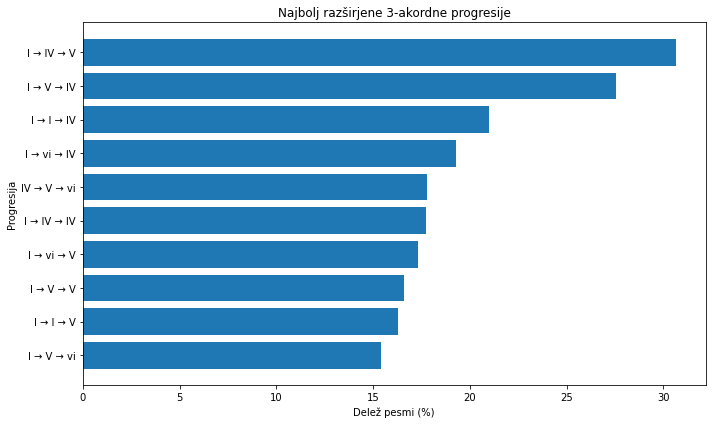

In [34]:
top_10_progresij = pogostost_3_po_pesmih_df.head(10).copy()
top_10_progresij["progresija"] = top_10_progresij["progresija"].apply(
    lambda p: " → ".join(p)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_progresij["progresija"][::-1],
    top_10_progresij["delez_pesmi"][::-1]
)

plt.xlabel("Delež pesmi (%)")
plt.ylabel("Progresija")
plt.title("Najbolj razširjene 3-akordne progresije")
plt.tight_layout()
plt.show()

### 6.2 Najpogostejše 4-akordne progresije po pesmih

Enako analizo izvedemo še za vzorce dolžine 4.

In [35]:
pogostost_4_po_pesmih = (
    pesmi_zanesljive["razlicni_vzorci_4_brez_ponovitev"]
    .explode()
    .dropna()
    .value_counts()
)

# Pregledna tabela:
pogostost_4_po_pesmih_df = (
    pogostost_4_po_pesmih
    .rename_axis("progresija")
    .reset_index(name="stevilo_pesmi")
)

pogostost_4_po_pesmih_df["delez_pesmi"] = (
    pogostost_4_po_pesmih_df["stevilo_pesmi"]
    / len(pesmi_zanesljive)
    * 100
).round(2)

pogostost_4_po_pesmih_df.head(10)

,progresija,stevilo_pesmi,delez_pesmi
0,"(I, IV, I, V)",3024,19.13
1,"(I, IV, I, IV)",2320,14.68
2,"(I, V, IV, V)",2250,14.24
3,"(I, IV, V, IV)",1948,12.33
4,"(I, V, vi, IV)",1843,11.66
5,"(I, IV, IV, V)",1691,10.70
6,"(I, I, IV, V)",1664,10.53
7,"(I, V, I, V)",1573,9.95
8,"(I, vi, IV, V)",1546,9.78
9,"(I, V, vi, V)",1507,9.54


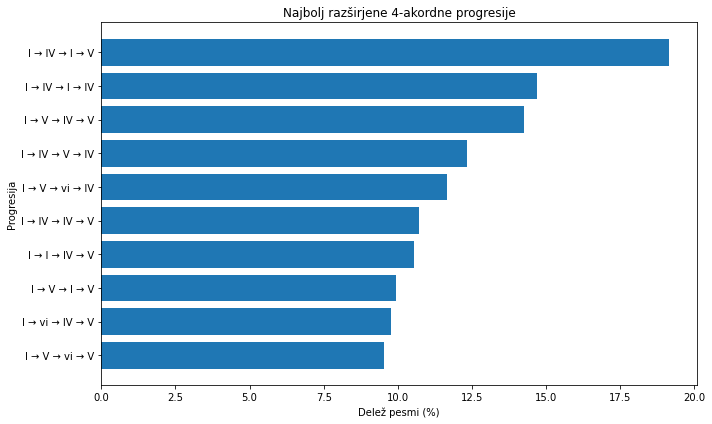

In [36]:
top_10_progresij = pogostost_4_po_pesmih_df.head(10).copy()
top_10_progresij["progresija"] = top_10_progresij["progresija"].apply(
    lambda p: " → ".join(p)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_progresij["progresija"][::-1],
    top_10_progresij["delez_pesmi"][::-1]
)

plt.xlabel("Delež pesmi (%)")
plt.ylabel("Progresija")
plt.title("Najbolj razširjene 4-akordne progresije")
plt.tight_layout()
plt.show()

### 6.3 Skupno število pojavitev

Pri tej analizi pa ne štejemo, v koliko pesmih se vzorec pojavi, temveč kolikokrat se pojavi vse skupaj.
Na ta rezultat imajo veliko vpliva daljše in bolj *repetitivne* pesmi.

In [37]:
pogostost_3_vseh_pojavitev_df = (
    pesmi_zanesljive["vzorci_3_brez_ponovitev"]
    .explode()
    .dropna()
    .value_counts()
    .rename_axis("progresija")
    .reset_index(name="stevilo_pojavitev")
)

pogostost_4_vseh_pojavitev_df = (
    pesmi_zanesljive["vzorci_4_brez_ponovitev"]
    .explode()
    .dropna()
    .value_counts()
    .rename_axis("progresija")
    .reset_index(name="stevilo_pojavitev")
)

print("3-akordne progresije:")
display(pogostost_3_vseh_pojavitev_df.head(10))

print("4-akordne progresije:")
display(pogostost_4_vseh_pojavitev_df.head(10))


3-akordne progresije:


,progresija,stevilo_pojavitev
0,"(I, IV, V)",66123
1,"(I, V, IV)",65127
2,"(I, vi, IV)",36538
3,"(I, I, IV)",31133
4,"(IV, V, vi)",29037
5,"(VI, VII, i)",27967
6,"(I, IV, IV)",24429
7,"(I, vi, V)",24098
8,"(I, V, vi)",22449
9,"(VI, i, VII)",21278


4-akordne progresije:


,progresija,stevilo_pojavitev
0,"(I, V, vi, IV)",39487
1,"(I, IV, I, IV)",33932
2,"(I, IV, I, V)",32334
3,"(III, VII, i, VI)",22744
4,"(I, V, IV, V)",17724
5,"(I, vi, IV, V)",16489
6,"(I, vi, V, IV)",16213
7,"(I, V, I, V)",15939
8,"(I, IV, vi, V)",12452
9,"(I, IV, V, IV)",12327


## 7. Harmonska raznolikost posameznih pesmi

Za vsako pesem preštejemo, koliko različnih 4-akordnih vzorcev vsebuje. Manjše število pomeni, da je struktura pesmi bolj ponavljajoča, večje število pa, da je bolj raznolika.

**Opomba**: Pesmi brez veljavnega 4-akordnega vzorca iz te analize izločimo. Pri njih zaradi kratkega zaporedja, nediatoničnih akordov ali manjkajočih podatkov ni bilo mogoče določiti nobenega primernega vzorca.

In [38]:
pesmi_zanesljive["stevilo_razlicnih_vzorcev_4"] = (
    pesmi_zanesljive["razlicni_vzorci_4_brez_ponovitev"]
    .apply(len)
)

pesmi_z_vzorci = pesmi_zanesljive[
    pesmi_zanesljive["stevilo_razlicnih_vzorcev_4"] > 0
].copy()

Poglejmo, koliko pesmi uporablja natanko en 4-akordni vzorec.

In [39]:
stevilo_pesmi_z_enim_vzorcem = (
    pesmi_z_vzorci["stevilo_razlicnih_vzorcev_4"] == 1
).sum()

delez_pesmi_z_enim_vzorcem = (
    stevilo_pesmi_z_enim_vzorcem / len(pesmi_z_vzorci) * 100
)

print(f"Pesmi z natanko eno različno progresijo: {stevilo_pesmi_z_enim_vzorcem}")
print(f"Delež: {delez_pesmi_z_enim_vzorcem:.2f} %")

Pesmi z natanko eno različno progresijo: 943
Delež: 8.27 %


Zdaj preštejemo, koliko pesmi ima posamezno število različnih vzorcev:

In [40]:
porazdelitev_stevila_vzorcev = (
    pesmi_z_vzorci["stevilo_razlicnih_vzorcev_4"]
    .value_counts()
    .sort_index()
)

# Pregledna tabela:
porazdelitev_stevila_vzorcev_df = (
    porazdelitev_stevila_vzorcev
    .rename_axis("stevilo_razlicnih_vzorcev")
    .reset_index(name="stevilo_pesmi")
)

porazdelitev_stevila_vzorcev_df["delez_pesmi"] = (
    porazdelitev_stevila_vzorcev_df["stevilo_pesmi"]
    / len(pesmi_z_vzorci)
    * 100
).round(2)

porazdelitev_stevila_vzorcev_df.head(15)

,stevilo_razlicnih_vzorcev,stevilo_pesmi,delez_pesmi
0,1,943,8.27
1,2,475,4.17
2,3,693,6.08
3,4,664,5.83
4,5,705,6.19
5,6,688,6.04
6,7,671,5.89
7,8,661,5.80
8,9,555,4.87
9,10,613,5.38


In [41]:
def skupina_stevila_vzorcev(stevilo):
    """Števila od 1 do 9 pustimo nespremenjena,
    vrednosti 10 ali več pa združimo v skupino '10+'."""

    if stevilo >= 10:
        return "10+"

    return str(stevilo)


# Ustvari skupine:
pesmi_z_vzorci["skupina_stevila_vzorcev"] = (
    pesmi_z_vzorci["stevilo_razlicnih_vzorcev_4"]
    .apply(skupina_stevila_vzorcev)
)

# Določi pravilen vrstni red skupin:
vrstni_red = [
    "1", "2", "3", "4", "5",
    "6", "7", "8", "9", "10+"
]

# Preštejemo pesmi:
porazdelitev_skupin = (
    pesmi_z_vzorci["skupina_stevila_vzorcev"]
    .value_counts()
    .reindex(vrstni_red, fill_value=0)
)

porazdelitev_skupin


1       943
2       475
3       693
4       664
5       705
6       688
7       671
8       661
9       555
10+    5341
Name: skupina_stevila_vzorcev, dtype: int64

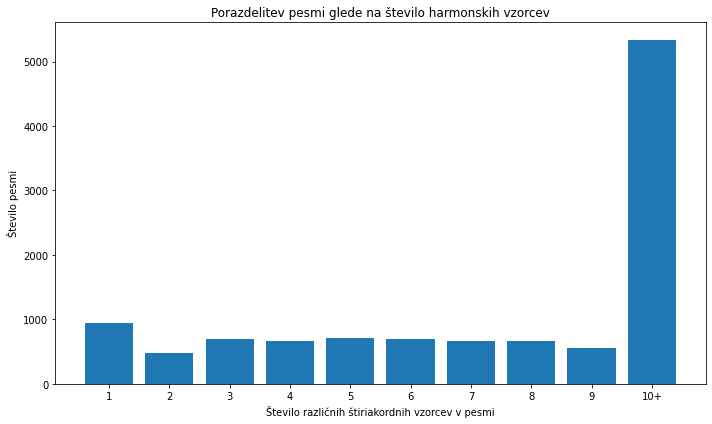

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    porazdelitev_skupin.index,
    porazdelitev_skupin.values
)

plt.xlabel("Število različnih štiriakordnih vzorcev v pesmi")
plt.ylabel("Število pesmi")
plt.title("Porazdelitev pesmi glede na število harmonskih vzorcev")

plt.tight_layout()
plt.show()


## 8. Harmonska osredotočenost najpogostejših izvajalcev

Za 10 izvajalcev z največ pesmimi v zbirki določimo:

- število njihovih pesmi,
- najpogostejšo 4-akordno progresijo,
- število pojavitev te progresije,
- delež te najpogostejše 4-akordne progresije med vsemi pojavitvami progresij v pesmih tega izvajalca.

Večji delež najpogostejše progresije torej pomeni, da ima izvajalec neko tipično strukturo pesmi oz. da so njegove pesmi s tega vidika manj raznolike.

Najprej poiščemo 10 najpogostejših izvajalcev:

In [43]:
top_10_izvajalcev = (
    pesmi_zanesljive["izvajalec"]
    .value_counts()
    .head(10)
)

Za vsakega analiziramo progresije:

In [44]:
def analiza_progresij(df):
    """
    Vrne osnovne podatke o izvajalcu:
    - število pesmi,
    - najpogostejšo štiriakordno progresijo,
    - število pojavitev,
    - delež vseh progresij.
    """

    vse_progresije = []

    for progresije in df["vzorci_4_brez_ponovitev"]:
        vse_progresije.extend(progresije)

    if len(vse_progresije) == 0:
        return None

    stevec = Counter(vse_progresije)

    progresija, stevilo = stevec.most_common(1)[0]

    return {
        "stevilo_pesmi": len(df),
        "najpogostejsa_progresija": progresija,
        "stevilo_pojavitev": stevilo,
        "delez": stevilo / len(vse_progresije)
    }

Ustvarimo tabelo:

In [45]:
rezultati_izvajalcev = []

for izvajalec in top_10_izvajalcev.index:

    podatki = analiza_progresij(
        pesmi_zanesljive[
            pesmi_zanesljive["izvajalec"] == izvajalec
        ]
    )

    if podatki is not None:
        podatki["izvajalec"] = izvajalec
        rezultati_izvajalcev.append(podatki)

analiza_izvajalcev = pd.DataFrame(rezultati_izvajalcev)


# Polepšamo tabelo:
analiza_izvajalcev["delez"] = (
    analiza_izvajalcev["delez"] * 100
).round(2)

analiza_izvajalcev = analiza_izvajalcev[
    [
        "izvajalec",
        "stevilo_pesmi",
        "najpogostejsa_progresija",
        "stevilo_pojavitev",
        "delez"
    ]
]

analiza_izvajalcev

,izvajalec,stevilo_pesmi,najpogostejsa_progresija,stevilo_pojavitev,delez
0,The Beatles,121,"(I, IV, I, IV)",584,13.59
1,Bob Dylan,79,"(I, IV, I, IV)",1216,15.08
2,Imagine Dragons,79,"(III, VII, i, VI)",197,5.83
3,Oasis,78,"(I, IV, I, IV)",244,7.57
4,Coldplay,69,"(I, V, vi, IV)",184,4.36
5,Ed Sheeran,63,"(I, V, vi, IV)",719,11.83
6,Lana Del Rey,63,"(VI, VII, i, VII)",282,6.65
7,Arctic Monkeys,63,"(i, iv, i, iv)",233,7.13
8,Hillsong Worship,57,"(I, V, vi, IV)",776,15.03
9,Bruce Springsteen,57,"(I, IV, I, IV)",485,11.91


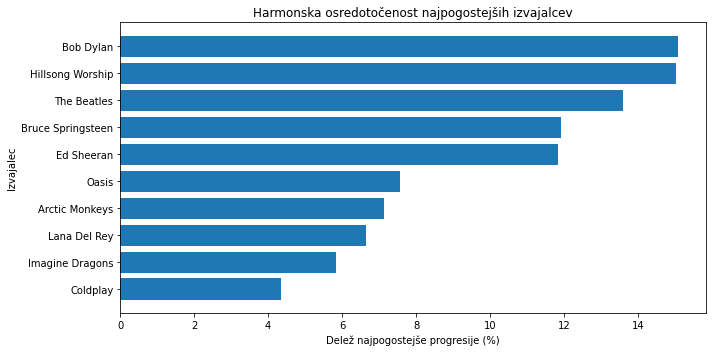

In [46]:
analiza_izvajalcev = analiza_izvajalcev.sort_values("delez")

plt.figure(figsize=(10, 5))

plt.barh(
    analiza_izvajalcev["izvajalec"],
    analiza_izvajalcev["delez"]
)

plt.xlabel("Delež najpogostejše progresije (%)")
plt.ylabel("Izvajalec")
plt.title("Harmonska osredotočenost najpogostejših izvajalcev")
plt.tight_layout()
plt.show()

## 9. Harmonska osredotočenost žanrov

Enako analizo izvedemo še za 10 najpogostejših žanrov.
Za vsak žanr določimo:

- število pesmi,
- najpogostejšo 4-akordno progresijo,
- število pojavitev te progresije,
- delež najpogostejše progresije glede na vse progresije žanra.

Večji delež pomeni, da ena progresija predstavlja večji del vseh opaženih 4-akordnih progresij znotraj tega žanra, torej da ima žanr neko tipično harmonsko strukturo.

In [47]:
# Poiščemo najpogostejše žanre
top_10_zanrov = (
    pesmi_zanesljive["zanr"]
    .value_counts()
    .head(10)
)

top_10_zanrov

Pop            5099
Rock           3067
Alternative    1956
Country        1084
Folk            838
Worship         779
R&B             712
Latin           578
Hip-hop         486
Electronic      310
Name: zanr, dtype: int64

In [48]:
rezultati_zanrov = []

for zanr in top_10_zanrov.index:
    podatki = analiza_progresij(
        pesmi_zanesljive[pesmi_zanesljive["zanr"] == zanr]
    )

    if podatki is not None:
        podatki["zanr"] = zanr
        rezultati_zanrov.append(podatki)

analiza_zanrov = pd.DataFrame(rezultati_zanrov)

analiza_zanrov["najpogostejsa_progresija"] = (
    analiza_zanrov["najpogostejsa_progresija"]
    .apply(lambda p: " → ".join(p))
)

analiza_zanrov["delez"] = (
    analiza_zanrov["delez"] * 100
).round(2)

analiza_zanrov = analiza_zanrov[
    [
        "zanr",
        "stevilo_pesmi",
        "najpogostejsa_progresija",
        "stevilo_pojavitev",
        "delez"
    ]
]

analiza_zanrov

,zanr,stevilo_pesmi,najpogostejsa_progresija,stevilo_pojavitev,delez
0,Pop,5099,I → V → vi → IV,17508,5.86
1,Rock,3067,I → IV → I → IV,8373,5.04
2,Alternative,1956,I → IV → I → IV,4495,4.86
3,Country,1084,I → IV → I → V,7226,14.76
4,Folk,838,I → IV → I → IV,4086,8.56
5,Worship,779,I → V → vi → IV,5555,11.07
6,R&B,712,I → IV → I → IV,1192,4.30
7,Latin,578,I → V → I → V,2646,8.74
8,Hip-hop,486,III → VII → i → VI,913,3.35
9,Electronic,310,I → V → vi → IV,778,5.36


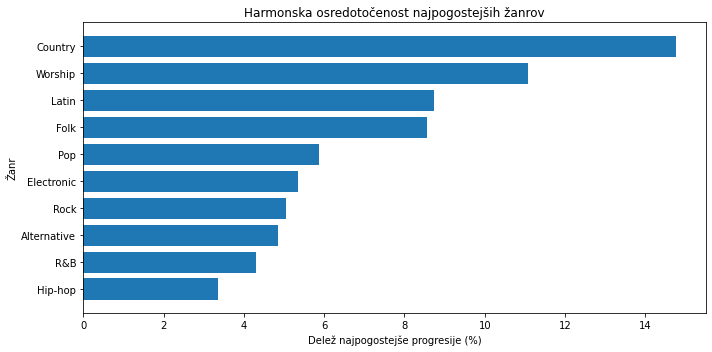

In [49]:
# Graf:
plt.figure(figsize=(10, 5))

analiza_zanrov = analiza_zanrov.sort_values("delez")

plt.barh(
    analiza_zanrov["zanr"],
    analiza_zanrov["delez"]
)

plt.xlabel("Delež najpogostejše progresije (%)")
plt.ylabel("Žanr")
plt.title("Harmonska osredotočenost najpogostejših žanrov")

plt.tight_layout()
plt.show()

### 9.1 Tipične 4-akordne progresije po žanrih

Iz prejšnje analize lahko razberemo tudi, katera štiriakordna progresija se najpogosteje pojavlja v posameznem žanru. Izkušeno uho namreč v posameznem žanru pogosto lahko sliši tipični vzorec (sploh npr. pri *country* in *worship* pesmih).

In [50]:
tipicne_progresije = (
    analiza_zanrov[
        [
            "zanr",
            "stevilo_pesmi",
            "najpogostejsa_progresija",
            "delez"
        ]
    ]
    .copy()
)

# Preimenujemo stolpce.
tipicne_progresije = tipicne_progresije.rename(
    columns={
        "zanr": "Žanr",
        "stevilo_pesmi": "Število pesmi",
        "najpogostejsa_progresija": "Tipična progresija",
        "delez": "Delež (%)"
    }
)

# Razvrstimo po deležu
tipicne_progresije = tipicne_progresije.sort_values(
    by="Delež (%)",
    ascending=False
)

tipicne_progresije

,Žanr,Število pesmi,Tipična progresija,Delež (%)
3,Country,1084,I → IV → I → V,14.76
5,Worship,779,I → V → vi → IV,11.07
7,Latin,578,I → V → I → V,8.74
4,Folk,838,I → IV → I → IV,8.56
0,Pop,5099,I → V → vi → IV,5.86
9,Electronic,310,I → V → vi → IV,5.36
1,Rock,3067,I → IV → I → IV,5.04
2,Alternative,1956,I → IV → I → IV,4.86
6,R&B,712,I → IV → I → IV,4.30
8,Hip-hop,486,III → VII → i → VI,3.35


## 10. Tempo pesmi po žanrih

Za konec izkoristimo še izluščen podatek o tempu in primerjajmo žanre po "hitrosti pesmi". BPM najprej pretvorimo v številski zapis in odstranimo manjkajoče vrednosti.

Za primerjavo uporabimo:

- tabelo s številom pesmi, povprečjem, mediano in standardnim odklonom,
- škatlo z brki, ki pokaže mediano, srednjih 50 % vrednosti in razpršenost tempa.

Ker imajo žanri različno število pesmi, je smiselno uporabiti primerjavo porazdelitve.

In [51]:
podatki_bpm = pesmi[["zanr", "bpm"]].copy()

podatki_bpm["bpm"] = pd.to_numeric(
    podatki_bpm["bpm"],
    errors="coerce" # neštevilske vrednosti pretvori v NaN, ki jih nato odstranim
)

podatki_bpm = podatki_bpm.dropna(subset=["zanr", "bpm"])

top_10_zanrov_bpm = (
    podatki_bpm["zanr"]
    .value_counts()
    .head(10)
    .index
)

podatki_bpm_top = podatki_bpm[
    podatki_bpm["zanr"].isin(top_10_zanrov_bpm)
].copy()

In [52]:
statistika_bpm_po_zanrih = (
    podatki_bpm_top
    .groupby("zanr")["bpm"]
    .agg(
        stevilo_pesmi="count",
        povprecje="mean",
        mediana="median",
        standardni_odklon="std"
    )
    .round(1)
    .sort_values("mediana", ascending=False)
)

statistika_bpm_po_zanrih

,stevilo_pesmi,povprecje,mediana,standardni_odklon
zanr,,,,
Electronic,328,117.7,123.0,23.3
Rock,3356,114.7,112.0,34.9
Alternative,2056,106.9,103.0,32.5
Latin,601,111.4,102.0,36.9
Folk,859,104.8,100.0,31.2
Country,1119,102.1,98.0,29.7
Pop,5560,100.5,97.0,27.8
R&B,826,94.2,92.0,24.9
Hip-hop,513,95.9,90.0,23.8


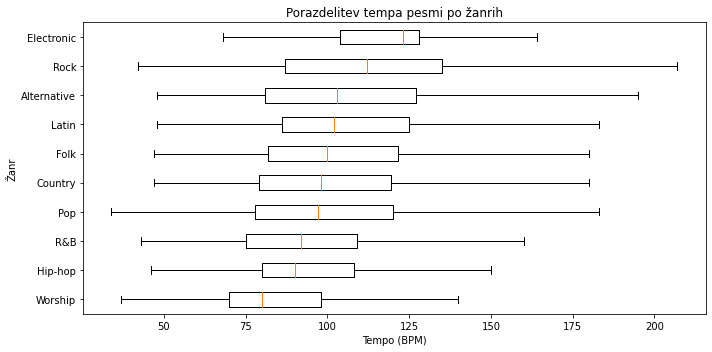

In [53]:
vrstni_red_bpm= (
    statistika_bpm_po_zanrih
    .sort_values("mediana")
    .index
    .tolist()
)

podatki_za_graf = [
    podatki_bpm_top.loc[podatki_bpm_top["zanr"] == zanr, "bpm"]
    for zanr in vrstni_red_bpm
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    podatki_za_graf,
    labels=vrstni_red_bpm,
    showfliers=False,
    vert=False
)

plt.xlabel("Tempo (BPM)")
plt.ylabel("Žanr")
plt.title("Porazdelitev tempa pesmi po žanrih")
plt.tight_layout()
plt.show()

Škatla z brki omogoča primerjavo tipičnega tempa in razpršenosti med žanri. Višja mediana pomeni, da so pesmi v tem žanru hitrejše, daljša škatla pa kaže večjo razpršenost tempa. 

Tako po povprečju kot po mediani imajo med analiziranimi žanri najvišji tempo pesmi žanra Electronic, najnižjega pa pesmi žanra Worship. Tak rezultat bi tudi pričakovali.

## 11. Zaključek

Analize sem se lotila, ker pri glasbenih izvajalcih in posameznih žanrih včasih opazim *repetitivnost* oz. nek značilen vzorec v njihovih pesmih. Tako lahko npr. ogromno pesmi na kitari zaigram le s 4 akordi. Zanimalo me je, kateri vzorci so v priljubljenih pesmih in posameznih žanrih najpogostejši.

Z izčrpno analizo glasbenih značilnosti 17.106 pesmi smo pridobili podatke o najpogostejših akordih in harmonskih vzorcih oz. progresijah. Nato smo analizirali, koliko in kateri vzorci se ponavljajo pri posameznih izvajalcih in žanrih. Za konec smo naredili tudi analizo tempa pesmi po žanrih.

**OPOMBA:** Edini zajet podatek, ki ga nismo uporabili, je leto izdaje pesmi. V nadaljnji analizi bi lahko pogledali spreminjanje najpogostejših vzorcev skozi čas.

V pregledovanju in analizi podatkov smo se med drugim srečali z naslednjimi izzivi: 
- transponiranje akordov s podatkom o kapodastru,
- ocenjevanje ustreznosti podatka o tonaliteti, korekcija tega podatka glede na dejanske pripadajoče akorde, izločevanje manj zanesljivih pesmi za harmonsko analizo,
- pretvorba akordov v stopnje glede na tonaliteto s slovarji,
- uporaba drsečega okna za iskanje vzorcev ter
- enačenje vseh cikličnih zamikov vzorca z enim samim predstavnikom.
